In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.style.use ('ggplot')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/ahmedosman220/netflix-shows/Netflix_data.csv')
df.head()

,sho_id,Typ,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(5398, 12)

In [4]:
# Q1
# sho_id is not important column because we have pandas index
df.drop(columns='sho_id',inplace=True)
# we will do one modification to index of pandas to start form 1 
df.index=df.index+1


In [5]:
#Q2
df.rename(columns={'Typ':'type'},inplace=True)
df['type'].unique() # I found TV Show Written in many Values
correct={
    'TVShow':'TV Show',
    'TV Sh':'TV Show'}
df['type']=df['type'].replace(correct)


df['duration'].value_counts()
df.loc[df['duration'].str.contains('Season',case=False,na=False,),'type']='TV Show'
df.loc[df['duration'].str.contains('Seasons',case=False,na=False,),'type']='TV Show'
df.loc[df['duration'].str.contains('min',case=False,na=False,),'type']='Movie'





In [6]:
#Q3
df.isnull().sum() # We Know the most three are directore and cast and country 
df.drop(index=5398,inplace=True)
df # I want to delete it because it not important 
df['director']=df['director'].replace(np.nan,'Unknown')
df['cast']=df['cast'].replace(np.nan,'Unknown')
df['country']=df['country'].replace(np.nan,'Unknown')



In [7]:
#َQ4
df['date_added']=pd.to_datetime(df['date_added']) 
df['day_added']=df['date_added'].dt.day_name()
df['month_added']=df['date_added'].dt.month_name()
df['year_added']=df['date_added'].dt.year


/tmp/ipykernel_17/3735740432.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added']=pd.to_datetime(df['date_added'])


In [8]:
# Q5 
c=[ 
df['date_added'].dt.month.isin([12,1,2]),
df['date_added'].dt.month.isin([3,4,5]),
df['date_added'].dt.month.isin([6,7,8]),
df['date_added'].dt.month.isin([9,10,11])
]
t=['Winter','Spring','Summer','Autumn']
df['season']=np.select(c,t,default='Unknown')


In [9]:
# Q6 
df['year_added'].mode()

0    2020
Name: year_added, dtype: int32

In [10]:
#Q7
df['rating'].mode()

0    TV-MA
Name: rating, dtype: object

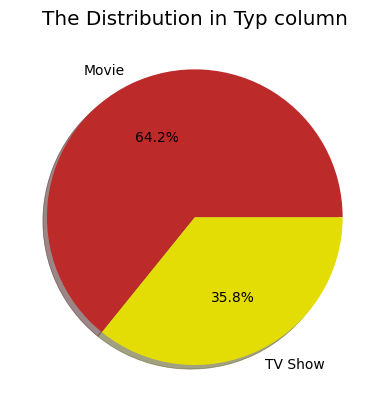

In [11]:
#Q8
x=df['type'].value_counts()
size=x.values
label=x.index
color=['#bd2a2a','#e3dc05']

plt.pie(size,labels=label,colors=color,autopct='%1.1f%%',shadow=True)
plt.title("The Distribution in Typ column")
plt.show()

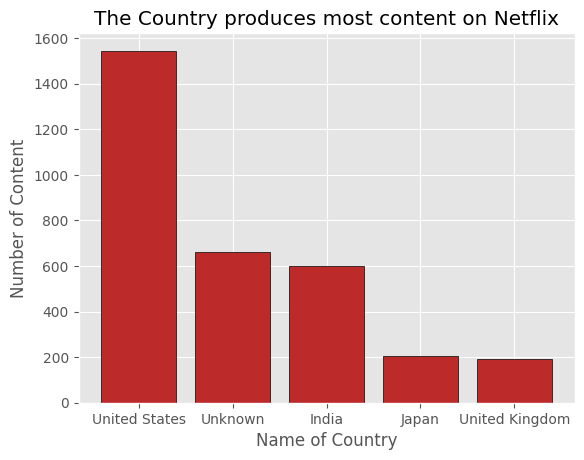

In [12]:
#Q9

y=df['country'].value_counts().head()
name=y.index
value=y.values

plt.bar(name,value,color='#bd2a2a',edgecolor='black')
plt.title('The Country produces most content on Netflix')
plt.ylabel("Number of Content")
plt.xlabel("Name of Country")
plt.show()

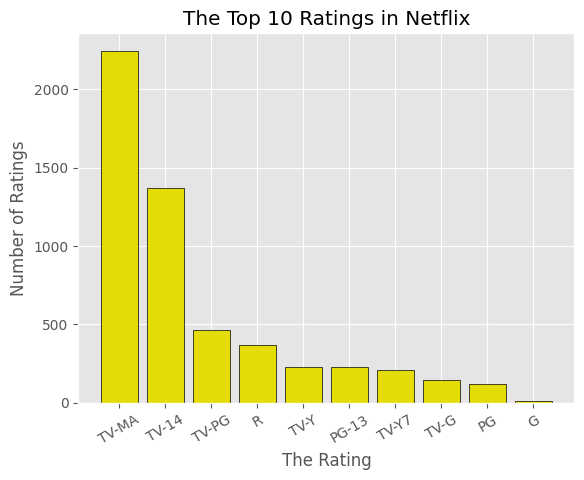

In [13]:
#Q10

r=df['rating'].value_counts().head(10)
num=r.values
type=r.index

plt.bar(type,num,color='#e3dc05',edgecolor='black')
plt.title('The Top 10 Ratings in Netflix')
plt.xlabel('The Rating')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=30)
plt.show()

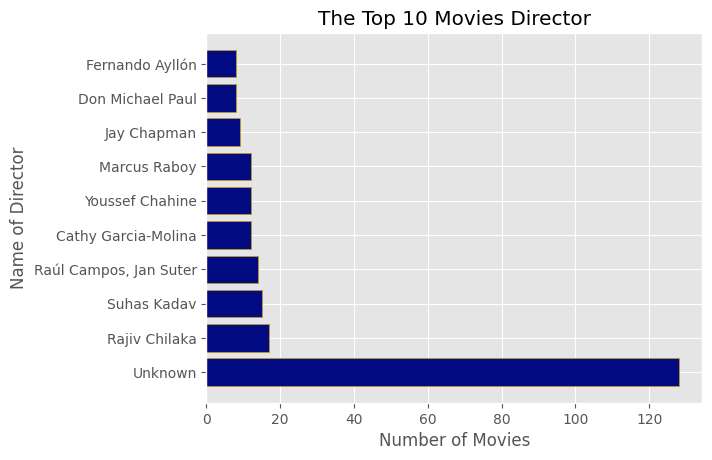

In [14]:
#Q11
a=df.loc[df['type'].str.contains('Movie'),'director'].value_counts().head(10)
num=a.values
name=a.index

plt.barh(name,num,color="#020b82",edgecolor="#CE9D0B")
plt.title('The Top 10 Movies Director')
plt.ylabel('Name of Director')
plt.xlabel('Number of Movies')
plt.show()


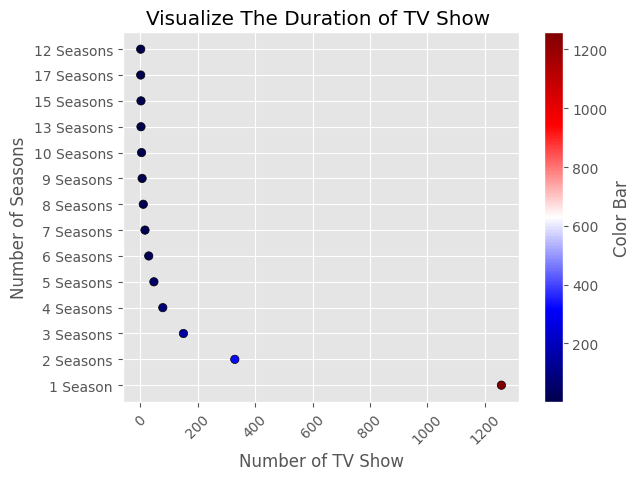

In [15]:
#Q12
d=df.loc[df['type'].str.contains("TV Show"),'duration'].value_counts()
season=d.index
num=d.values

plt.scatter(num,season,edgecolor='black',c=num,cmap='seismic')
c=plt.colorbar()
c.set_label('Color Bar')
plt.title('Visualize The Duration of TV Show ')
plt.xlabel('Number of TV Show')
plt.ylabel('Number of Seasons')
plt.xticks(rotation=45)
plt.show()


In [16]:
#Q13
r=df['cast'].str.split(',')
df['actor 1']=r.str[0]
df['actor 2']=r.str[1]
df['actor 2']=df['actor 2'].replace(np.nan,'No more')


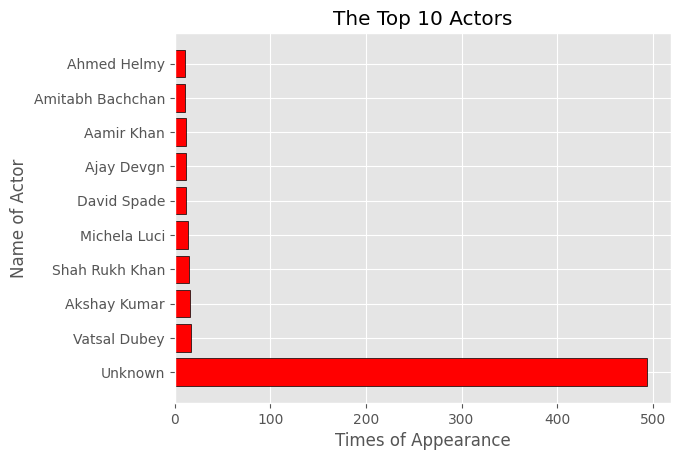

In [17]:
#Q14
c=df['actor 1'].value_counts().head(10)
name =c.index
app=c.values

plt.barh(name,app,edgecolor='black',color='red')
plt.title('The Top 10 Actors')
plt.xlabel('Times of Appearance')
plt.ylabel('Name of Actor')
plt.show()
